In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359

maxval=1e9
minval=1e-9

2025-05-25 21:19:26.964263: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-25 21:19:26.964331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-25 21:19:26.965537: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-25 21:19:26.973248: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-25 21:19:28.000978: W tensorflow/compiler/tf2

In [2]:
os.chdir('SmartPix/data_generator')
!pwd

/home/das214/SmartPix/data_generator


In [3]:
#from dataprep import *
# from OptimizedDataGenerator import OptimizedDataGenerator
from loss import *
from models import *

In [4]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/"
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_base_dir = os.path.join(dataset_base_dir, "parquets")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = 75
val_file_size = 25

In [23]:
import os
import gc
import math
import glob
import random
import logging
import datetime
import numpy as np
import pandas as pd

from typing import Union, List, Tuple
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

from tqdm import tqdm
import tensorflow as tf
from qkeras import quantized_bits

import utils


# custom quantizer

# @tf.function
def QKeras_data_prep_quantizer(data, bits=4, int_bits=0, alpha=1):
    """
    Applies QKeras quantization.
    Args:
        data (tf.Tensor): Input data (tf.Tensor).
        bits (int): Number of bits for quantization.
        int_bits (int): Number of integer bits.
        alpha (float): (don't change)
    Returns::
        tf.Tensor: Quantized data (tf.Tensor).
    """
    quantizer = quantized_bits(bits, int_bits, alpha=alpha)
    return quantizer(data)


def split_df_to_X_y_df(df: pd.DataFrame,
                       labels_list: List[str],
                       recon_cols: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:

    X_df = df[recon_cols].copy()
    y_df = df[labels_list].copy()

    return X_df, y_df


In [64]:
# OptimizedDataGeneratorNew


class OptimizedDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, 
            dataset_base_dir: str = "./",
            is_directory_recursive: bool = False,
            batch_size: int = 32,
            file_count = None,
            labels_list: Union[List,str] = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
            to_standardize: bool = False,
            input_shape: Tuple = (13,21),
            transpose = None,
            include_y_local: bool = False,
            files_from_end = False,
            shuffle=False,

            # Added in Optimized datagenerators 
            load_from_tfrecords_dir: str = None,
            tfrecords_dir: str = None,
            use_time_stamps = -1,
            seed: int = None,
            quantize: bool = False,
            max_workers: int = 1,
                 
            **kwargs,
            ):
        super().__init__() 

        self.shuffle = shuffle
        if shuffle:
            self.seed = seed if seed is not None else 13
            self.rng = np.random.default_rng(seed = self.seed)
        
        # If data is already prepared load anduse that data
        if load_from_tfrecords_dir is not None:
            self.file_offsets = [None]
            if not os.path.isdir(load_from_tfrecords_dir):
                raise ValueError(f"Directory {load_from_tfrecords_dir} does not exist.")
            else:
                self.tfrecords_dir = load_from_tfrecords_dir
        else:
            n_time, height, width = input_shape
            
            if use_time_stamps == -1:
                use_time_stamps = list(np.arange(0,20))
            assert len(use_time_stamps) == n_time, f"Expected {n_time} time steps, got {len(use_time_stamps)}"
    
            len_xy = height * width
            col_indices = [
                np.arange(t * len_xy, (t + 1) * len_xy).astype(str)
                for t in use_time_stamps
            ]
            self.use_time_stamps = list(np.arange(0,20)) if use_time_stamps == -1 else use_time_stamps
            self.recon_cols = np.concatenate(col_indices).tolist()
    
    
    
            self.max_workers = max_workers
            self.shuffle = shuffle

            
            self.files = sorted(glob.glob(os.path.join(dataset_base_dir, "part.*.parquet"), recursive=False))
    
            if file_count != None:
                if not files_from_end:
                    self.files = self.files[:file_count]
                else:
                    self.files = self.files[-file_count:]
    
    
            self.file_offsets = [0]
            self.dataset_mean = None
            self.dataset_std = None

            # safe_remove_directory(tfrecords_dir)
            utils.safe_remove_directory(tfrecords_dir)
            self.batch_size = batch_size
            self.labels_list = labels_list
            self.input_shape = input_shape
            self.transpose = transpose
            self.to_standardize = to_standardize
            self.include_y_local = include_y_local

            self.process_file_parallel()
    
            self.current_file_index = None
            self.current_dataframes = None
    
            if tfrecords_dir is None:
                raise ValueError(f"tfrecords_dir is None")
                
            self.tfrecords_dir = tfrecords_dir    
            os.makedirs(self.tfrecords_dir, exist_ok=True)
            self.save_batches_parallel() # save all the batches
            del self.current_dataframes 
            
        self.tfrecord_filenames = np.sort(np.array(tf.io.gfile.glob(os.path.join(self.tfrecords_dir, "*.tfrecord"))))
        self.quantize = quantize
        self.epoch_count = 0
        self.on_epoch_end()


    def process_file_parallel(self):
        file_infos = [(afile, self.recon_cols, self.input_shape, self.transpose) for afile in self.files]
        results = []
        with ProcessPoolExecutor(self.max_workers) as executor:
            futures = [executor.submit(self._process_file_single, file_info) for file_info in file_infos]
            for future in tqdm(as_completed(futures), total=len(file_infos), desc="Processing Files..."):
                results.append(future.result())

        for amean, avariance, amin, amax, num_rows in results:
            self.file_offsets.append(self.file_offsets[-1] + num_rows)

            if self.dataset_mean is None:
                self.dataset_max = amax
                self.dataset_min = amin
                self.dataset_mean = amean
                self.dataset_std = avariance
            else:
                self.dataset_max = max(self.dataset_max, amax)
                self.dataset_min = min(self.dataset_min, amin)
                self.dataset_mean += amean
                self.dataset_std += avariance

        self.dataset_mean = self.dataset_mean / len(self.files)
        self.dataset_std = np.sqrt(self.dataset_std / len(self.files)) 
            
        self.file_offsets = np.array(self.file_offsets)

    @staticmethod
    def _process_file_single(file_info):
        afile, recon_cols, input_shape, transpose = file_info

        adf = pd.read_parquet(afile, columns=recon_cols)

        x = adf.values
        nonzeros = abs(x) > 0
        x[nonzeros] = np.sign(x[nonzeros]) * np.log1p(abs(x[nonzeros])) / math.log(2)
        amean, avariance = np.mean(x[nonzeros], keepdims=True), np.var(x[nonzeros], keepdims=True) + 1e-10
        centered = np.zeros_like(x)
        centered[nonzeros] = (x[nonzeros] - amean) / np.sqrt(avariance)
        x = x.reshape((-1, *input_shape))
        if transpose is not None:
            x = x.transpose(transpose)
        amin, amax = np.min(centered), np.max(centered)
        len_adf = len(adf)

        del adf
        gc.collect()
        
        return amean, avariance, amin, amax, len_adf

    def standardize(self, x, norm_factor_pos=1.7, norm_factor_neg=2.5):
        """
        Applies the normalization configuration in-place to a batch of inputs.
        `x` is changed in-place since the function is mainly used internally
        to standardize images and feed them to your network.
        Args:
            x: Batch of inputs to be normalized.
        Returns:
            The inputs, normalized. 
        """
        out = (x - self.dataset_mean)/self.dataset_std
        out[out > 0] = out[out > 0]/norm_factor_pos
        out[out < 0] = out[out < 0]/norm_factor_neg
        return out

    def save_batches_parallel(self):
        """
        Saves data batches as multiple TFRecord files.
        """
        # TODO: Make this parallelized
        num_batches = self.__len__() # Total num of batches
        paths_or_errors = []

        # The max_workers is set to 1 because processing large batches in multiple threads can significantly
        # increase RAM usage. Adjust 'max_workers' based on your system's RAM capacity and requirements.
        with ThreadPoolExecutor(max_workers=1) as executor:
            future_to_batch = {executor.submit(self.save_single_batch, i): i for i in range(num_batches)}
            
            for future in tqdm(as_completed(future_to_batch), total=num_batches, desc="Saving batches as TFRecords"):
                result = future.result()
                paths_or_errors.append(result)
            
        for res in paths_or_errors:
            if "Error" in res:
                print(res)  
                
    def save_single_batch(self, batch_index):
        """
        Serializes and saves a single batch to a TFRecord file.
        Args:
            batch_index (int): Index of the batch to save.
        Returns:
            str: Path to the saved TFRecord file or an error message.
        """
        
        try:
            filename = f"batch_{batch_index}.tfrecord"
            TFRfile_path = os.path.join(self.tfrecords_dir, filename)
            X, y = self.prepare_batch_data(batch_index)
            serialized_example = self.serialize_example(X, y)
            with tf.io.TFRecordWriter(TFRfile_path) as writer:
                writer.write(serialized_example)
            return TFRfile_path
        except Exception as e:
            return f"Error saving batch {batch_index}: {e}" 
        
    def prepare_batch_data(self, batch_index):
        """
        Fetch and prepare one batch (X, y).
        """
        abs_idx = batch_index * self.batch_size # absolute *event* index
        
        file_idx = (np.arange(self.file_offsets.size)[abs_idx < self.file_offsets][0] - 1) # first index is 0!

        rel_idx = abs_idx - self.file_offsets[file_idx]
        stop_idx = min(rel_idx + self.batch_size, self.file_offsets[file_idx + 1] - self.file_offsets[file_idx])

        if file_idx != self.current_file_index:
            self.current_file_index = file_idx
            parquet_file = self.files[file_idx]

            recon_df = pd.read_parquet(parquet_file, columns=self.recon_cols)
            labels_df = pd.read_parquet(parquet_file, columns=self.labels_list)

            has_nans = np.any(np.isnan(recon_df.values), axis=1)
            has_nans = np.arange(recon_df.shape[0])[has_nans]
            recon_df_raw = recon_df.drop(has_nans)
            labels_df_raw = labels_df.drop(has_nans)

            joined_df = recon_df_raw.join(labels_df_raw)

            if self.shuffle: # Changed
                joined_df = joined_df.sample(frac=1, random_state=self.seed).reset_index(drop=True)  

            recon_values = joined_df[recon_df_raw.columns].values            

            nonzeros = abs(recon_values) > 0
            
            recon_values[nonzeros] = np.sign(recon_values[nonzeros])*np.log1p(abs(recon_values[nonzeros]))/math.log(2)
            
            if self.to_standardize:
                recon_values[nonzeros] = self.standardize(recon_values[nonzeros])
            
            recon_values = recon_values.reshape((-1, *self.input_shape))            
                        
            if self.transpose is not None:
                recon_values = recon_values.transpose(self.transpose)
            
            self.current_dataframes = (
                recon_values, 
                joined_df[labels_df_raw.columns].values,
            )        
        
        recon_df, labels_df = self.current_dataframes

        X = recon_df[rel_idx:stop_idx]
        y = labels_df[rel_idx:stop_idx] / np.array([75., 18.75, 8.0, 0.5])
    
        if self.include_y_local:
            y_local = labels_df.iloc[rel_idx:stop_idx]["y-local"].values
            return [X, y_local], y
        else:
            return X, y
    
    def serialize_example(self, X, y):
        """
        Serializes a single example (featuresand labels) to TFRecord format. 
        
        Args:
        - X: Training data
        - y: labelled data
        
        Returns:
        - string (serialized TFRecord example).
        """
        # X and y are float32 (maybe we can reduce this)
        X = tf.cast(X, tf.float32)
        y = tf.cast(y, tf.float32)

        feature = {
            'X': self._bytes_feature(tf.io.serialize_tensor(X)),
            'y': self._bytes_feature(tf.io.serialize_tensor(y)),
        }
        example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
        return example_proto.SerializeToString()

    @staticmethod
    def _bytes_feature(value):
        """
        Converts a string/byte value into a Tf feature of bytes_list
        
        Args: 
        - string/byte value
        
        Returns:
        - tf.train.Feature object as a bytes_list containing the input value.
        """
        if isinstance(value, type(tf.constant(0))): # check if Tf tensor
            value = value.numpy()
        return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

    def __getitem__(self, batch_index):
        """
        Load the batch from a pre-saved TFRecord file instead of processing raw data.
        Each file contains exactly one batch.
        quantization is done here: Helpful for pretraining without the quantization and the later training with quantized data.
        shuffling is also done here.
        TODO: prefetching (un-done)
        """
        tfrecord_path = self.tfrecord_filenames[batch_index]
        raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
        parsed_dataset = raw_dataset.map(self._parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)

        for X_batch, y_batch in parsed_dataset:
            ''' Add the reshaping in saving'''
            X_batch = tf.reshape(X_batch, [-1, *X_batch.shape[1:]])
            y_batch = tf.reshape(y_batch, [-1, *y_batch.shape[1:]])

            if self.quantize:
                X_batch = QKeras_data_prep_quantizer(X_batch, bits=4, int_bits=0, alpha=1)

            if self.shuffle:
                indices = tf.range(start=0, limit=tf.shape(X_batch)[0], dtype=tf.int32)
                shuffled_indices = tf.random.shuffle(indices, seed=self.seed)
                X_batch = tf.gather(X_batch, shuffled_indices)
                y_batch = tf.gather(y_batch, shuffled_indices)
                
            del raw_dataset, parsed_dataset
            return X_batch, y_batch
            
    @staticmethod
    def _parse_tfrecord_fn(example):
        """
        Parses a single TFRecord example.
        
        Returns:
        - X: as a float32 tensor.
        - y: as a float32 tensor.
        """
        feature_description = {
            'X': tf.io.FixedLenFeature([], tf.string),
            'y': tf.io.FixedLenFeature([], tf.string),
        }
        example = tf.io.parse_single_example(example, feature_description)
        X = tf.io.parse_tensor(example['X'], out_type=tf.float32)
        y = tf.io.parse_tensor(example['y'], out_type=tf.float32)
        return X, y

    def __len__(self):
        if len(self.file_offsets) != 1: # used when TFRecord files are created during initialization
            num_batches = self.file_offsets[-1] // self.batch_size
        else: # used during loading saved TFRecord files
            num_batches = len(os.listdir(self.tfrecords_dir))
        return num_batches

    def on_epoch_end(self):
        '''
        This shuffles the file ordering so that it shuffles the ordering in which the TFRecord
        are loaded during the training for each epochs.
        '''
        gc.collect()
        self.epoch_count += 1
        # Log quantization status once
        if self.epoch_count == 1:
            logging.warning(f"Quantization is {self.quantize} in data generator. This may affect model performance.")

        if self.shuffle:
            self.rng.shuffle(self.tfrecord_filenames)
            self.seed += 1 # So that after each epoch the batch is shuffled with a different seed (deterministic)

In [65]:
# start_time = time.time()
# validation_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_base_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = val_batch_size,
#     file_count = val_file_size,
#     to_standardize= True,
#     include_y_local= False,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (20,13,21), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, 
#     files_from_end=True,

#     tfrecords_dir = tfrecords_dir_val,
#     use_time_stamps = -1,
#     max_workers = 2
# )

# print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# # training generator
# start_time = time.time()
# training_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_base_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = batch_size,
#     file_count = train_file_size,
#     to_standardize= True,
#     include_y_local= False,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (20,13,21), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, # True 

#     tfrecords_dir = tfrecords_dir_train,
#     use_time_stamps = -1,
#     max_workers = 2
# )
# print("--- Training generator %s seconds ---" % (time.time() - start_time))

In [66]:
start_time = time.time()
validation_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_base_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = val_batch_size,
    file_count = val_file_size,
    to_standardize= True,
    include_y_local= False,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, 
    files_from_end=True,

    tfrecords_dir = tfrecords_dir_val,
    use_time_stamps = [0,19],
    max_workers = 2
)

print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# training generator
start_time = time.time()
training_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_base_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = batch_size,
    file_count = train_file_size,
    to_standardize= True,
    include_y_local= False,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, # True 

    tfrecords_dir = tfrecords_dir_train,
    use_time_stamps = [0,19],
    max_workers = 2
)
print("--- Training generator %s seconds ---" % (time.time() - start_time))

Directory /depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/TFR_files/2t/TFR_val is removed...


Saving batches as TFRecords: 100%|██████████| 101/101 [00:22<00:00,  4.54it/s]


--- Validation generator 33.44460415840149 seconds ---
Directory /depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/TFR_files/2t/TFR_train is removed...


Saving batches as TFRecords: 100%|██████████| 305/305 [01:04<00:00,  4.74it/s]


--- Training generator 93.34976363182068 seconds ---


In [67]:
# training_generator = OptimizedDataGenerator(
#     load_from_tfrecords_dir = tfrecords_dir_train,
#     shuffle = False,
#     seed = 13,
#     quantize = False
# )

# validation_generator = OptimizedDataGenerator(
#     load_from_tfrecords_dir = tfrecords_dir_val,
#     shuffle = False,
#     seed = 13,
#     quantize = False
# )


In [71]:
print(training_generator.files[0])

df1 = pd.read_parquet(training_generator.files[0])
display(df1.head())
X_df, y_df = split_df_to_X_y_df(df1, training_generator.labels_list, training_generator.recon_cols)

display(X_df.head())
display(y_df.head())

/depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/parquets/part.0.parquet


,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,pt,cotAlpha,...,5450,5451,5452,5453,5454,5455,5456,5457,5458,5459
__null_dask_index__,,,,,,,,,,,,,,,,,,,,,
9873,289.192169,-5.131680,100.0,-15.733156,-0.144582,-2.223809,74363.0,-2.18237,-2.2285,7.074868,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7672,354.942749,14.270715,100.0,-11.739238,-0.096295,-2.073261,53449.0,-1.14559,2.0755,5.662209,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38477,-158.251556,13.312810,100.0,7.123054,-0.191513,-2.117858,26232.0,-2.46897,2.1265,-3.363329,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33588,42.867229,5.449532,100.0,0.601822,0.354247,-1.853957,7955.0,5.44644,-1.8875,-0.324615,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,467.314484,10.443373,100.0,-13.184443,-0.202864,-1.537175,75199.0,-3.62055,1.5505,8.577061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,0,1,2,3,4,5,6,7,8,9,...,5450,5451,5452,5453,5454,5455,5456,5457,5458,5459
__null_dask_index__,,,,,,,,,,,,,,,,,,,,,
9873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7672,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38477,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,-14.5,-12.0,-137.5,0.7,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,x-midplane,y-midplane,cotAlpha,cotBeta
__null_dask_index__,,,,
9873,-64.551251,-8.382454,7.074868,0.065015
7672,71.832277,11.948407,5.662209,0.046446
38477,9.914912,8.791426,-3.363329,0.090428
33588,59.097972,15.003340,-0.324615,-0.191076
4997,38.461458,3.844775,8.577061,0.131972


In [73]:
X_array = X_df.values.reshape((-1, *training_generator.input_shape)) 
X_array = X_array.transpose(training_generator.transpose)
X_array = np.sign(X_array)*np.log1p(abs(X_array))/math.log(2)
X_array = training_generator.standardize(X_array)

y_array = y_df.values/ np.array([75., 18.75, 8.0, 0.5])

event_id = 0


In [74]:
target_feat = X_array[event_id]            # shape (t,h,w)
target_lab  = y_array[event_id]            # already /[75,18.75,8,0.5]


def same_label(a, b, tol=1e-6):
    return np.allclose(a, b, atol=tol)

found = False
for b in tqdm(range(len(training_generator))):
    Xb, yb = training_generator[b]
    Xb, yb = Xb.numpy(), yb.numpy()        # tensors → numpy

    for e in range(len(yb)):
        if same_label(yb[e], target_lab):
            found = True
            print(f"Match: batch {b}, event {e}")
            gen_feat = Xb[e]               # (t,h,w)
            break
    if found:
        break

if not found:
    print("Label vector not found in generator batches!")



  0%|          | 0/305 [00:00<?, ?it/s]

Match: batch 0, event 0


In [75]:
features_np, labels_np = training_generator[b]
features_np = features_np.numpy()
labels_np = labels_np.numpy()


Label: [-0.8606833  -0.4470642   0.8843585   0.13003094]


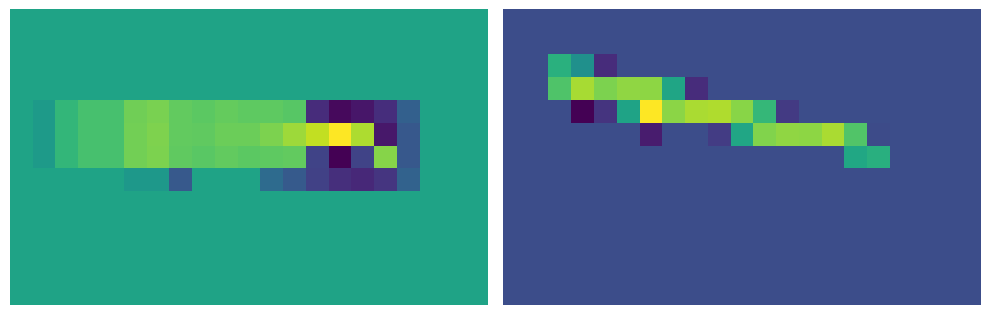


Label: [-0.86068334 -0.4470642   0.88435855  0.13003095]


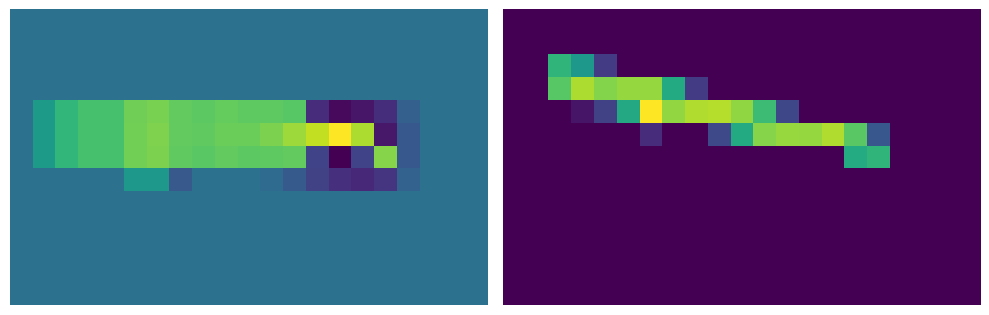

In [76]:
event_id = e

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
for i in range(2):
    matrix = features_np[event_id, :, :, i]
    # print(f"\nFeature channel {i} matrix:")
    # for row in matrix:
        # row_str = "".join(f"{val:6.1f}" for val in row)
        # print(row_str)

    axes[i].imshow(matrix) 
    axes[i].axis('off')

print("\nLabel:", labels_np[event_id])
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
for i in range(2):
    matrix = X_array[event_id, :, :, i]
    # print(f"\nFeature channel {i} matrix:")
    # for row in matrix:
    #     row_str = "".join(f"{val:6.1f}" for val in row)
    #     print(row_str)

    axes[i].imshow(matrix) 
    axes[i].axis('off')

print("\nLabel:", y_array[event_id])
plt.tight_layout()
plt.show()

In [77]:
model=CreateModel((13,21,2),n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
    loss=custom_loss
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d_1 (QSep  (None, 11, 19, 5)         33        
 arableConv2D)                                                   
                                                                 
 q_activation_5 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                                 
 q_conv2d_1 (QConv2D)        (None, 11, 19, 5)         30        
                                                                 
 q_activation_6 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                           

In [14]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'
os.makedirs(base_dir, exist_ok=True)  
checkpoint_filepath = base_dir + '/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [15]:
print(fingerprint)

80dbcbd2


In [16]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback

early_stopping_patience = 50

class CustomModelCheckpoint(ModelCheckpoint):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        checkpoints = [f for f in os.listdir(base_dir) if f.startswith('weights')]
        if len(checkpoints) > 1:
            checkpoints.sort()
            for checkpoint in checkpoints[:-1]:
                os.remove(os.path.join(base_dir, checkpoint))

es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = CustomModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    save_best_only=True,
    save_freq='epoch',
    verbose=1
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [17]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        callbacks=[es, mcp, csv_logger],
        epochs=1000,
        shuffle=False,
        verbose=1
    )

Epoch 1/1000


2025-05-25 21:21:26.946605: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-05-25 21:21:27.031643: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-05-25 21:21:27.547192: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x7fae8d840160
2025-05-25 21:21:30.003888: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa0fd66e160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-25 21:21:30.003950: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB MIG 1g.5gb, Compute Capability 8.0
2025-05-25 21:21:30.015795: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748200890.155814  741333 device_compiler.h:186] Compiled

305/305 [==============================] - ETA: 0s - loss: 26679.5684
Epoch 1: val_loss improved from inf to 11783.82129, saving model to ./trained_models/model-80dbcbd2-checkpoints/weights.01-t26679.57-v11783.82.hdf5
305/305 [==============================] - 94s 285ms/step - loss: 26679.5684 - val_loss: 11783.8213
Epoch 2/1000
305/305 [==============================] - ETA: 0s - loss: 10763.4951
Epoch 2: val_loss improved from 11783.82129 to 10095.14844, saving model to ./trained_models/model-80dbcbd2-checkpoints/weights.02-t10763.50-v10095.15.hdf5
305/305 [==============================] - 26s 85ms/step - loss: 10763.4951 - val_loss: 10095.1484
Epoch 3/1000
305/305 [==============================] - ETA: 0s - loss: 9877.0352
Epoch 3: val_loss improved from 10095.14844 to 9463.44434, saving model to ./trained_models/model-80dbcbd2-checkpoints/weights.03-t9877.04-v9463.44.hdf5
305/305 [==============================] - 28s 91ms/step - loss: 9877.0352 - val_loss: 9463.4443
Epoch 4/1000

KeyboardInterrupt: 